# 04 — Typologie des joueuses (PCA + clustering)

C'est ici que l'analyse de *style* a vraiment du sens : ~200 joueuses (échantillon large,
contrairement aux 12 équipes), profilées **par minute** (= leur **rôle**, pas leur volume
de jeu) + leur taille.

**Méthode.** PCA pour comprendre les axes de variation, puis k-means (k validé par
silhouette) pour les archétypes. Filtre : ≥ 8 matchs et ≥ 10 min/match (stats stables).

In [1]:
import sys
from pathlib import Path
p = Path.cwd()
while not (p / "analyse" / "outils.py").exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p / "analyse"))
import numpy as np, pandas as pd, outils as o
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
OUT = o.RESULTATS / "joueuses"; OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)
print("sorties ->", OUT)

sorties -> C:\Users\TEMP.IUT-LUMIERE.000\R6.06-Domaines-d-application-de-la-statistique\analyse\resultats\joueuses


## Profil par minute de chaque joueuse-saison

In [2]:
df = o.charger_equipes(o.SAISONS_COMPLETES)
j = df[df["Joueur"] != "TOTAUX EQUIPE"].copy()
g = j.groupby(["cle","Saison"]).agg(
        matchs=("Pts","size"), min_moy=("Tps_jeu_decimal","mean"), min_tot=("Tps_jeu_decimal","sum"),
        FGA=("Tirs_tentes","sum"), TPA=("3pts_tentes","sum"), FTA=("LF_tentes","sum"),
        PTS=("Pts","sum"), RO=("RO","sum"), RD=("RD","sum"), PD=("PD","sum"),
        BP=("BP","sum"), INT=("INT","sum"), CT=("CT","sum"), EVAL=("EVAL","sum")).reset_index()
g = g[(g["matchs"] >= 8) & (g["min_moy"] >= 10)].copy()
mn = g["min_tot"] + 1e-9
prof = pd.DataFrame({"cle":g["cle"], "Saison":g["Saison"], "min_moy":g["min_moy"]})
prof["tirs_min"]    = g["FGA"]/mn
prof["part_3pts"]   = g["TPA"]/(g["FGA"]+1e-9)
prof["pd_min"]      = g["PD"]/mn
prof["reb_off_min"] = g["RO"]/mn
prof["reb_def_min"] = g["RD"]/mn
prof["int_min"]     = g["INT"]/mn
prof["ct_min"]      = g["CT"]/mn
prof["fta_rate"]    = g["FTA"]/(g["FGA"]+1e-9)
prof["eval_min"]    = g["EVAL"]/mn
prof = prof.merge(o.tailles_par_cle(), on=["cle","Saison"], how="left")
role = ["tirs_min","part_3pts","pd_min","reb_off_min","reb_def_min","int_min","ct_min","fta_rate","taille"]
d = prof.dropna(subset=role).copy()
print(f"{len(prof)} joueuses-saisons, {len(d)} avec taille connue")

204 joueuses-saisons, 179 avec taille connue


## Axes principaux (PCA)

In [3]:
X = StandardScaler().fit_transform(d[role].values)
pca = PCA(n_components=4).fit(X)
print("variance expliquee (%):", np.round(pca.explained_variance_ratio_*100,1),
      "| cumul 2 axes:", round(pca.explained_variance_ratio_[:2].sum()*100), "%\n")
comp = pd.DataFrame(pca.components_[:2].T, index=role, columns=["axe1","axe2"]).round(2)
print(comp.sort_values("axe1").to_string())

variance expliquee (%): [38.8 21.1 10.5  7.7] | cumul 2 axes: 60 %

             axe1  axe2
part_3pts   -0.41  0.02
pd_min      -0.29  0.43
int_min     -0.04  0.58
tirs_min     0.02  0.53
fta_rate     0.27  0.22
ct_min       0.36 -0.04
reb_def_min  0.39  0.31
reb_off_min  0.44  0.12
taille       0.45 -0.17


**Lecture.** L'**axe 1** oppose taille + rebonds + contres (intérieures) à part de 3pts
+ passes (extérieures) : l'opposition **intérieure ↔ extérieure**, l'axe fondamental du
basket, que les données retrouvent seules. Bon signe de validité.

## Archétypes (k validé par silhouette)

In [4]:
for k in range(2,7):
    km = KMeans(n_clusters=k, n_init=25, random_state=0).fit(X)
    print(f"k={k} : silhouette = {silhouette_score(X, km.labels_):.3f}")
K = max(range(2,7), key=lambda k: silhouette_score(X, KMeans(n_clusters=k,n_init=25,random_state=0).fit_predict(X)))
print("-> k retenu :", K, "\n")
d["arch"] = KMeans(n_clusters=K, n_init=30, random_state=0).fit_predict(X)
d.to_csv(OUT / "joueuses_archetypes.csv", index=False)
z = (d[role]-d[role].mean())/d[role].std()
for c in sorted(d["arch"].unique()):
    idx = d["arch"]==c; moy = z[idx].mean().sort_values(ascending=False)
    plus = [f"{k_}(+{v:.1f})" for k_,v in moy.items() if v>=0.5][:4]
    moins= [f"{k_}({v:.1f})" for k_,v in moy.items() if v<=-0.5][-2:]
    print(f"Archetype {c}: n={idx.sum()}, taille {d[idx]['taille'].mean():.2f}m, impact/min {d[idx]['eval_min'].mean():.2f}")
    print("  +:", ", ".join(plus)); print("  -:", ", ".join(moins) or "-")

k=2 : silhouette = 0.245
k=3 : silhouette = 0.179
k=4 : silhouette = 0.180
k=5 : silhouette = 0.151
k=6 : silhouette = 0.164
-> k retenu : 2 

Archetype 0: n=77, taille 1.89m, impact/min 0.42
  +: taille(+0.8), reb_off_min(+0.8), reb_def_min(+0.7), ct_min(+0.6)
  -: pd_min(-0.5), part_3pts(-0.8)
Archetype 1: n=102, taille 1.77m, impact/min 0.31
  +: part_3pts(+0.6)
  -: reb_off_min(-0.6), taille(-0.6)


**Lecture.** k=2 ressort (meilleure silhouette) : la grande dichotomie **intérieures
(~1.89 m) / extérieures (~1.77 m)**. En forçant plus de groupes on retrouverait les postes
fins (meneuse / pivot / shooteuse / ailière). Surtout : dans chaque groupe l'impact/min
varie de stars à role-players → on a bien capturé le **rôle**, pas le niveau.

## Visualisation (plan PCA)

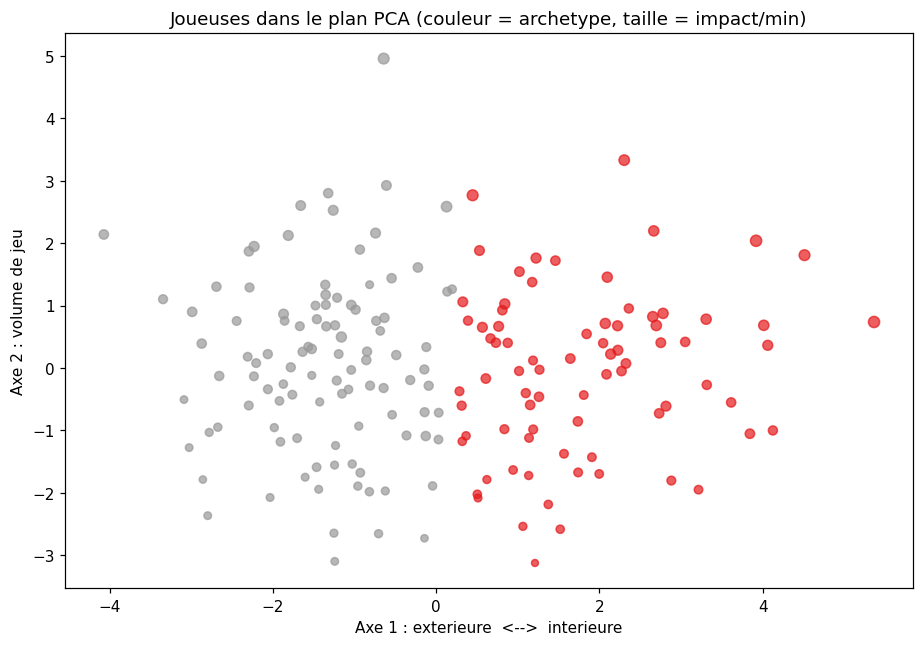

In [5]:
proj = pca.transform(X)
plt.figure(figsize=(8.5,6))
plt.scatter(proj[:,0], proj[:,1], c=d["arch"], cmap="Set1", s=20+d["eval_min"]*40, alpha=.7)
plt.xlabel("Axe 1 : exterieure  <-->  interieure")
plt.ylabel("Axe 2 : volume de jeu")
plt.title("Joueuses dans le plan PCA (couleur = archetype, taille = impact/min)")
plt.tight_layout(); plt.savefig(OUT / "joueuses_pca.png", dpi=130); plt.show()

## Conclusion

- La PCA **valide** la structure : l'axe intérieure/extérieure émerge des seules stats.
- Les archétypes correspondent aux **postes réels**, reconstruits sans jamais utiliser la
  colonne poste.
- Le **rôle est indépendant du niveau** → contrairement au style d'équipe (notebook 03),
  ici le clustering capture une vraie information.

**Usage recrutement** (volet prof) : regarder la répartition intérieures/extérieures d'un
effectif et cibler une recrue du profil manquant. Résultats dans `resultats/joueuses/`.